<a href="https://colab.research.google.com/github/Rishita0201/Github/blob/main/Yuva_Intern_Week_3_%E2%80%93_Unsupervised_Learning_and_Clustering_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [3]:
import pandas as pd

file_path = "dataset/Mall_Customers.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# Display basic information about the dataset

print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows:
0

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


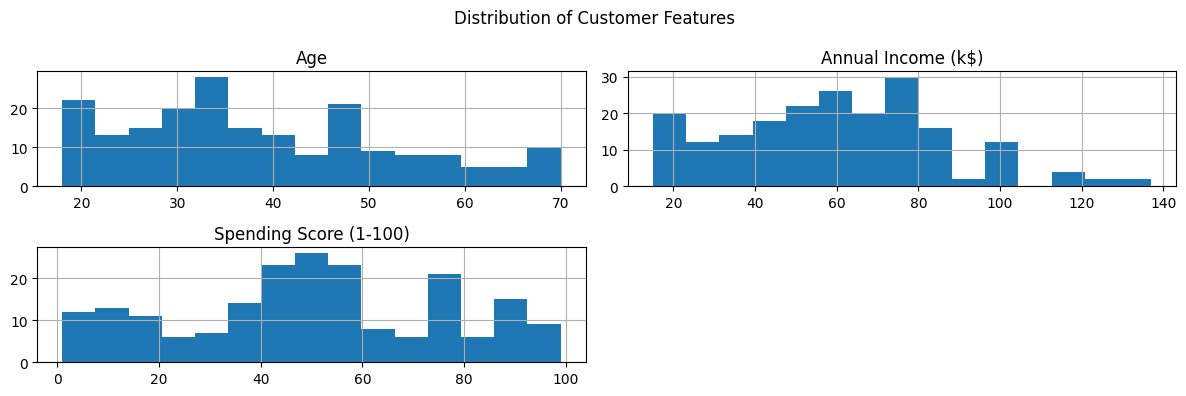

In [5]:
import matplotlib.pyplot as plt

# Select numerical columns
numeric_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Plot histograms
df[numeric_features].hist(figsize=(12, 4), bins=15)

plt.suptitle("Distribution of Customer Features")
plt.tight_layout()
plt.show()

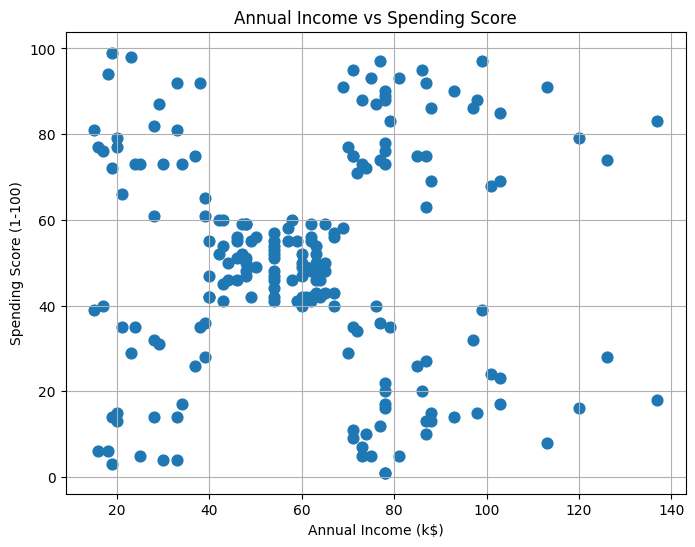

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    s=60
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")
plt.grid(True)

plt.show()

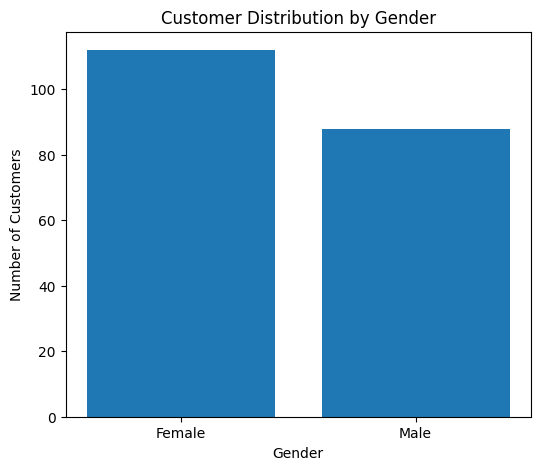

Gender
Female    112
Male       88
Name: count, dtype: int64


In [7]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6, 5))

plt.bar(gender_counts.index, gender_counts.values)

plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Gender")

plt.show()

print(gender_counts)

In [8]:
# Select features for clustering

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print("Selected features:")
display(X.head())

print("Shape of clustering data:", X.shape)

Selected features:


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Shape of clustering data: (200, 2)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardization completed!")

print("\nFirst 5 standardized records:")
print(X_scaled[:5])

Standardization completed!

First 5 standardized records:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [10]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=['Annual Income (Standardized)', 'Spending Score (Standardized)']
)

display(X_scaled_df.head())

print("\nMean after standardization:")
print(X_scaled_df.mean())

print("\nStandard deviation after standardization:")
print(X_scaled_df.std())

,Annual Income (Standardized),Spending Score (Standardized)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980



Mean after standardization:
Annual Income (Standardized)    -2.131628e-16
Spending Score (Standardized)   -1.465494e-16
dtype: float64

Standard deviation after standardization:
Annual Income (Standardized)     1.002509
Spending Score (Standardized)    1.002509
dtype: float64


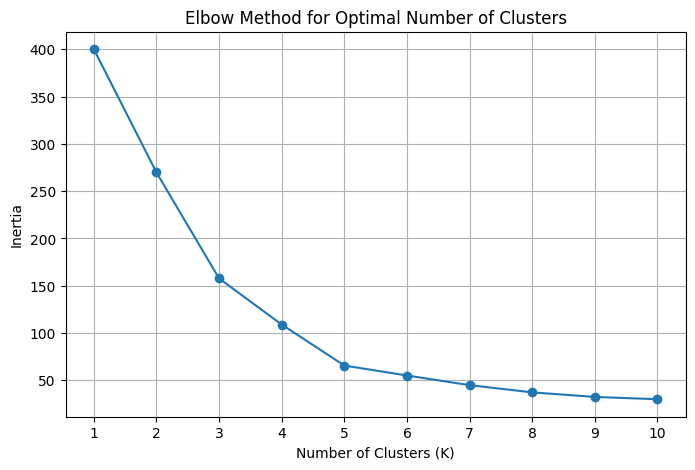

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate inertia for different numbers of clusters
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xticks(K_range)
plt.grid(True)

plt.show()

K = 2: Silhouette Score = 0.3213
K = 3: Silhouette Score = 0.4666
K = 4: Silhouette Score = 0.4939
K = 5: Silhouette Score = 0.5547
K = 6: Silhouette Score = 0.5399
K = 7: Silhouette Score = 0.5281
K = 8: Silhouette Score = 0.4552
K = 9: Silhouette Score = 0.4571
K = 10: Silhouette Score = 0.4432


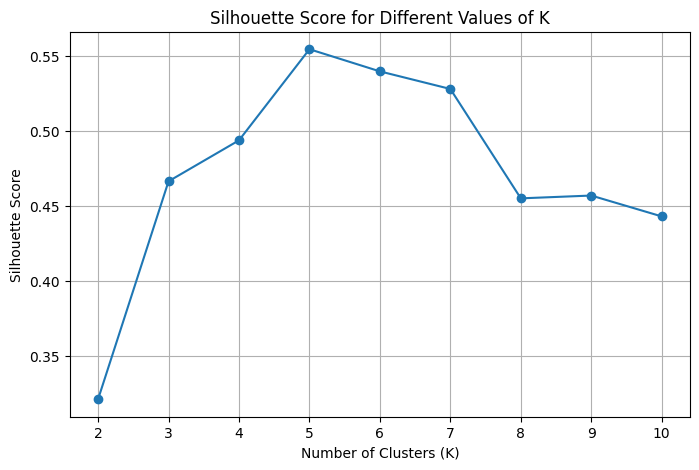

In [12]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Display scores
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Values of K")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [13]:
# Apply K-Means clustering

optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataset
df['Cluster'] = cluster_labels

print("K-Means clustering completed!")
print("Number of clusters:", optimal_k)

print("\nNumber of customers in each cluster:")
print(df['Cluster'].value_counts().sort_index())

K-Means clustering completed!
Number of clusters: 5

Number of customers in each cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [14]:
# Display customers with their cluster assignments

display(df.head(10))

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


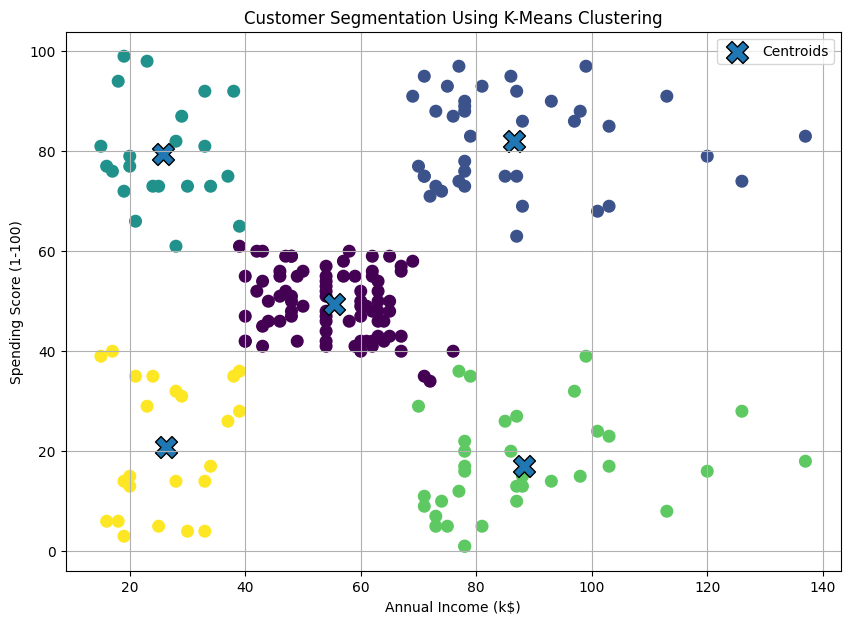

In [15]:
# Visualize the customer clusters

plt.figure(figsize=(10, 7))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=cluster_labels,
    s=70
)

# Plot cluster centroids
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='X',
    s=250,
    edgecolor='black',
    label='Centroids'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation Using K-Means Clustering")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
# Calculate average characteristics of each cluster

cluster_summary = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().round(2)

print("Cluster Characteristics:")
display(cluster_summary)

Cluster Characteristics:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


In [17]:
# Count customers in each cluster

cluster_counts = df['Cluster'].value_counts().sort_index()

print("Number of Customers in Each Cluster:")
print(cluster_counts)

Number of Customers in Each Cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [18]:
# Complete cluster profile

cluster_profile = df.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Average_Age=('Age', 'mean'),
    Average_Income=('Annual Income (k$)', 'mean'),
    Average_Spending=('Spending Score (1-100)', 'mean')
).round(2)

display(cluster_profile)

,Customers,Average_Age,Average_Income,Average_Spending
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


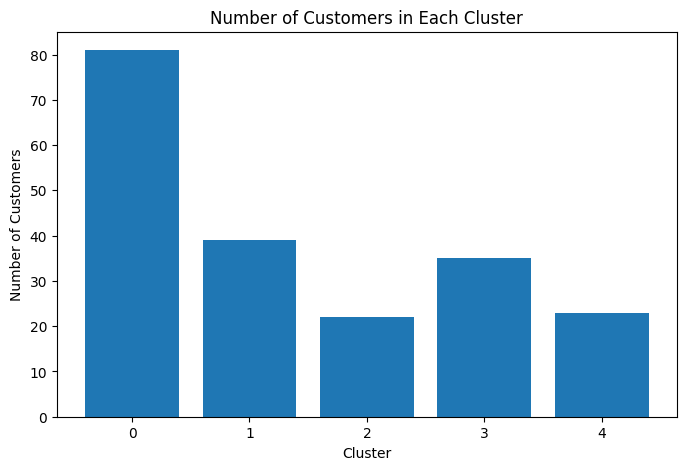

In [19]:
# Visualize the number of customers in each cluster

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")

plt.show()

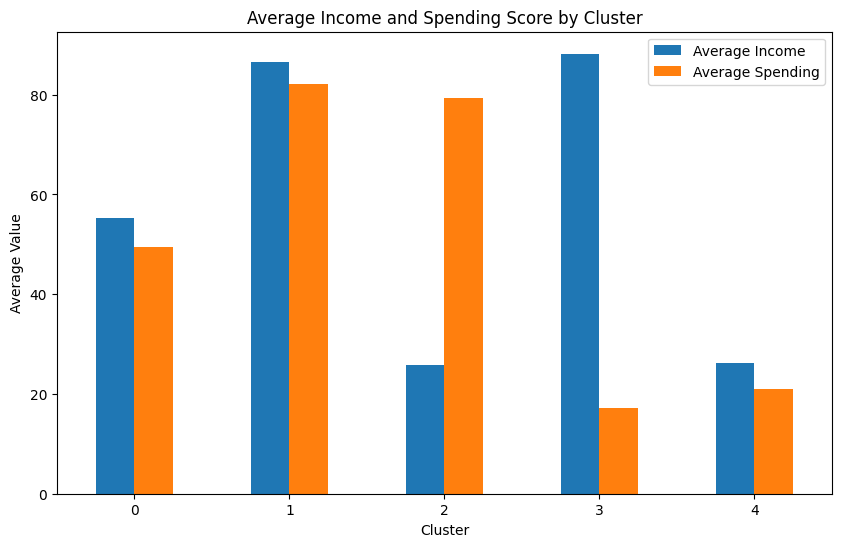

In [20]:
# Compare average income and spending score across clusters

cluster_profile[['Average_Income', 'Average_Spending']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.title("Average Income and Spending Score by Cluster")
plt.xticks(rotation=0)
plt.legend(["Average Income", "Average Spending"])

plt.show()

In [21]:
# Create a final summary table for the report

final_summary = cluster_profile.copy()

final_summary['Customer_Percentage'] = (
    final_summary['Customers'] / len(df) * 100
).round(2)

display(final_summary)

,Customers,Average_Age,Average_Income,Average_Spending,Customer_Percentage
Cluster,,,,,
0,81,42.72,55.30,49.52,40.5
1,39,32.69,86.54,82.13,19.5
2,22,25.27,25.73,79.36,11.0
3,35,41.11,88.20,17.11,17.5
4,23,45.22,26.30,20.91,11.5


In [22]:
from sklearn.metrics import silhouette_score

final_silhouette = silhouette_score(X_scaled, cluster_labels)

print(f"Final Silhouette Score: {final_silhouette:.4f}")

Final Silhouette Score: 0.5547


In [23]:
# Save the clustered dataset

output_file = "Mall_Customers_Clustered.csv"

df.to_csv(output_file, index=False)

print(f"Clustered dataset saved as: {output_file}")

Clustered dataset saved as: Mall_Customers_Clustered.csv


In [24]:
from google.colab import files

files.download("Mall_Customers_Clustered.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
print("Final Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Number of Clusters:", df['Cluster'].nunique())

print("\nFinal Cluster Distribution:")
print(df['Cluster'].value_counts().sort_index())

Final Dataset Shape: (200, 6)
Missing Values: 0
Duplicate Rows: 0
Number of Clusters: 5

Final Cluster Distribution:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64
